# Imports and Constants

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.backends.backend_pdf import PdfPages
import ast
from sklearn.utils import resample
from scipy import stats
from matplotlib import font_manager
from sys import platform

In [2]:
COLORS = {'treatment': '#006D29', 'T': '#006D29',
          'control': '#BBBBBB', 'C': '#BBBBBB'}

BAR_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c',
              '#d62728', '#9467bd']
LINE_COLORS = {'c1': '#1f77b4', 'c2': '#ff7f0e'}

CONDITION_GAP_SIZE = {'treatment': -0.1, 'control': 0.1}

JITTER_STD = 0.03

CONFIDENCE_LEVEL = 0.95
OUTLIER_Z_THRESHOLD = 2.5
BOOTSTRAP_N_SAMPLES = 1000

MARKER_SIZE = 50
MARKER_STYLES = {'user': 'o', 'agent': 's', 'tools': '^'}
MARKER_LINE_WIDTH = 0.4
MARKER_ALPHA = 0.5

LINE_WIDTHS = {'plot': 1.5, 'error_bar': 2, 'marker_edge': 2, 'grid': 0.8}
ERROR_BAR_SIZES = {'cap': 4, 'marker': 15, 'app_marker': 15, 'app_screen_marker': 15}
ERROR_BAR_CAPS = {'dot': 4, 'app_total': 4, 'app_screen': 4}
FILL_ALPHA = {'confidence': 0.3, 'time_series': 0.2}

GRID_ALPHA = 0.6
GRID_STYLE = '--'
SPINE_VISIBILITY = {'top': False, 'right': False, 'bottom': True, 'left': True}

FIGURE_SIZES = {
    'plan_overview': (9, 3),
    'chat_metrics': (9, 3.5),
    'app_usage_summary': (9, 3.5)
}

SUBPLOT_SPACING = {
    'plan': {'wspace': 0.45, 'hspace': 0.7},
    'app': {'wspace': 0.2, 'hspace': 0.7}
}

LEGEND_POSITIONS = {
    'plan': 'lower right',
    'app_screen': 'upper center',
    'chat': 'upper right'
}
LEGEND_COLS = 2

ROTATION_ANGLES = {'filter_category': 90}

FIGURE_MARGINS = {'left': 0.03, 'right': 0.99,
                  'top': 0.86, 'bottom': 0.08}
TIGHT_LAYOUT_RECT = [0, 0.03, 1, 0.95]

PLOT_COLUMNS = {'plan_overview': 4}

# Font loading
home_dir = os.path.expanduser('~')
fonts_path = '.fonts' if platform == "linux" else 'Library/Fonts'
font_dirs = [os.path.join(home_dir, fonts_path)]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
plt.rcParams.update({'font.family': 'Hanken Grotesk'})

# Matplotlib rcParams
mpl.rcParams.update({
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.titleweight": "semibold",
    "font.weight": 600,
    'axes.linewidth': 2,
    'lines.linewidth': 2,
    "axes.labelpad": 1,
})

# Seed
SEED = 0
np.random.seed(SEED)

# Quantitative Analysis

In [3]:
def get_week_bin(day):
    if 1 <= day <= 7:
        return 'week_1'
    elif 8 <= day <= 14:
        return 'week_2'
    elif 15 <= day <= 21:
        return 'week_3'
    elif 22 <= day <= 28:
        return 'week_4'
    else:
        return 'other'

def concatenate_and_get_unique_set(series):
    unique_items = set()
    for item in series:
        try:
            if pd.isna(item) or item in ['[]', '', 'nan']:
                continue
            if isinstance(item, str):
                parsed = ast.literal_eval(item.strip())
                if isinstance(parsed, list):
                    unique_items.update(parsed)
        except Exception as e:
            print(f"Error parsing item '{item}': {e}")
            continue
    return len(unique_items)

def calculate_ci(data, confidence):
    data = data.dropna()
    n = len(data)
    if n < 2:
        return (data.mean(), data.mean(), data.mean()) if n == 1 else (0, 0, 0)
    mean = data.mean()
    se = stats.sem(data)
    t_value = stats.t.ppf((1 + confidence) / 2., n - 1)
    ci = se * t_value
    return mean, mean - ci, mean + ci

def prepare_plan_data(df):
    df['week_bin'] = df['day'].apply(get_week_bin)
    df = df[df['week_bin'] != 'other']
    all_metrics = [
        'plan_workout_types_count',
        'plan_rounded',
        'plan_counts_per_day',
        'tool_call_errors_delete_workout',
        'tool_call_errors_add_workout',
        'tool_call_errors_generate_plan',
        'tool_calls_count_delete_workout',
        'tool_calls_count_add_workout',
        'plan_workout_duration',
        'plan_completed_workout_duration',
        'tool_calls_count_reschedule',
        'tool_calls_count_reschedule_errors',
        'tool_calls_count_generate_plan'
    ]
    plan_workout_types_count = df.groupby(['uid', 'week_bin'])['plan_workout_types'].apply(concatenate_and_get_unique_set).reset_index(name='plan_workout_types_count')
    weekly_sums = df.groupby(['uid', 'week_bin'])[[m for m in all_metrics if m != 'plan_workout_types_count']].sum().reset_index()
    weekly_sums = weekly_sums.merge(plan_workout_types_count, on=['uid', 'week_bin'], how='left')
    user_averages = weekly_sums.groupby(['uid'])[all_metrics].mean().reset_index()
    uid_condition_map = df[['uid', 'condition']].drop_duplicates()
    user_averages = user_averages.merge(uid_condition_map, on='uid', how='left')
    user_averages["plan_rounded"] = user_averages["plan_rounded"] / 7
    user_averages["plan_edit_count"] = user_averages['plan_counts_per_day'] - user_averages["tool_calls_count_reschedule"] - user_averages["tool_call_errors_delete_workout"] - user_averages["tool_call_errors_add_workout"] - user_averages["tool_call_errors_generate_plan"] + user_averages["tool_calls_count_reschedule_errors"]
    user_averages["plan_completion_rate"] = user_averages["plan_completed_workout_duration"] / user_averages["plan_workout_duration"]
    return user_averages

def plot_single_metric_dot(ax, user_averages, metric, subplot_label):
    for condition, color in COLORS.items():
        data = user_averages[user_averages['condition'] == condition][metric].dropna()
        std = np.std(data)
        if data.empty:
            continue

        x_pos = CONDITION_GAP_SIZE[condition]
        jitter = np.random.normal(0, JITTER_STD, size=len(data))
        ax.scatter(x_pos + jitter, data, color=color, s=MARKER_SIZE, 
                  alpha=MARKER_ALPHA, edgecolor='white', linewidth=MARKER_LINE_WIDTH)

        mean, ci_low, ci_high = calculate_ci(data, CONFIDENCE_LEVEL)

        ax.errorbar(x_pos, mean, yerr=[[mean - ci_low], [ci_high - mean]],
                    fmt='_', color='black', markersize=ERROR_BAR_SIZES['marker'], 
                    markeredgewidth=LINE_WIDTHS['error_bar'], 
                    capsize=ERROR_BAR_CAPS['dot'], capthick=LINE_WIDTHS['error_bar'])

        ax.text(x_pos + 0.015, mean, f" {mean:.2f}\n({std:.2f})",
                ha='left', va='center', color='black', fontweight='bold')

    ax.grid(True, axis='y', linestyle=GRID_STYLE, alpha=GRID_ALPHA, linewidth=LINE_WIDTHS['grid'])
    for spine, visible in SPINE_VISIBILITY.items():
        if spine in ['top', 'right', 'bottom']:
            ax.spines[spine].set_visible(visible)
    ax.tick_params(axis='y')

    positions = [CONDITION_GAP_SIZE["control"], CONDITION_GAP_SIZE["treatment"]]
    labels = ["Control", "Treatment"]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontweight="bold")
    
    ax.text(0.02, 0.98, subplot_label, transform=ax.transAxes, fontweight='bold', va='top', ha='left')
    ax.set_xlim(-0.2, 0.2)

def create_faceted_dot_plots(user_averages, metrics_config, pdf_path, figsize, n_cols=PLOT_COLUMNS['plan_overview']):
    num_metrics = len(metrics_config)
    n_rows = 1

    fig = plt.figure(figsize=figsize)
    
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, 
                          wspace=SUBPLOT_SPACING["plan"]['wspace'], 
                          hspace=SUBPLOT_SPACING["plan"]['hspace'])
    
    axes = [fig.add_subplot(gs[i, j]) for i in range(n_rows) for j in range(n_cols)]

    subplot_labels = ['A', 'B', 'C', 'D']
    
    for i, (metric, config) in enumerate(metrics_config.items()):
        ax = axes[i]
        plot_single_metric_dot(ax, user_averages, metric, subplot_labels[i])
        ax.set_title(config['label'], fontweight='bold', loc="center")
        ax.set_ylabel(config['ylabel'])
        if 'ylim' in config:
            ax.set_ylim(config['ylim'])
        if 'yticks' in config:
            ax.set_yticks(config['yticks'])

    for i in range(num_metrics, len(axes)):
        axes[i].set_visible(True)

    plt.subplots_adjust(left=FIGURE_MARGINS['left'], right=0.9, top=0.82, bottom=FIGURE_MARGINS['bottom'])
    plt.show()

    with PdfPages(pdf_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

In [4]:
def seconds_to_mmss(seconds):
    if pd.isna(seconds) or seconds == 0:
        return "0:00"
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"


def remove_outliers(data, z_threshold):
    z_scores = np.abs(stats.zscore(data.dropna()))
    return data[z_scores < z_threshold]

def bootstrap_ci(data, confidence_level=0.95, n_bootstrap=1000):
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        bootstrap_sample = resample(data, n_samples=len(data), random_state=None)
        bootstrap_means.append(np.mean(bootstrap_sample))
    
    alpha = 1 - confidence_level
    lower_percentile = (alpha/2) * 100
    upper_percentile = (1 - alpha/2) * 100
    
    mean = np.mean(data)
    ci_low = np.percentile(bootstrap_means, lower_percentile)
    ci_high = np.percentile(bootstrap_means, upper_percentile)
    
    return mean, ci_low, ci_high

def prepare_app_data(df):
    STATS = [
        "app_duration_today",
        "app_duration_today_chat",
        "app_duration_plan",
        "app_duration_insights",
        "app_duration_chat_history",
        "app_duration_journey_week_details",
        "app_duration_journey_screen",
    ]

    PLAN = ["app_duration_journey_week_details", "app_duration_plan", "app_duration_journey_screen"]
    CHATS = ["app_duration_chat_history", "app_duration_today_chat"]

    app_duration_cols = [
        "app_duration_plan",
        "app_duration_insights",
        "app_duration_today",
        "app_duration_settings",
        "app_duration_chat_history",
        "app_duration_today_chat",
        "app_duration_journey_week_details",
        "app_duration_journey_screen",
    ]

    df['app_usage_cleaned'] = df[app_duration_cols].sum(axis=1)

    df['plan'] = df[PLAN].sum(axis=1)
    df['chat'] = df[CHATS].sum(axis=1)

    individual_stats = [s for s in STATS if s not in PLAN + CHATS] + ["plan", "chat"]

    all_metrics = individual_stats + ["app_usage_cleaned"]
    weekly_sums = df.groupby(['uid', 'day'])[all_metrics].sum().reset_index()
    user_averages = weekly_sums.groupby(['uid'])[all_metrics].mean().reset_index()

    uid_condition_map = df[['uid', 'condition']].drop_duplicates()
    user_averages = user_averages.merge(uid_condition_map, on='uid', how='left')

    return user_averages, individual_stats, df


def calculate_app_usage_regression(df_filtered):
    results = {}
    
    for condition in ['treatment', 'control']:
        condition_data = df_filtered[df_filtered['condition'] == condition]
        condition_data = condition_data[condition_data['day'].between(1, 28)]
        
        if len(condition_data) == 0:
            continue
            
        daily_averages = condition_data.groupby('day')['app_usage_cleaned'].mean()
        
        days = daily_averages.index.values
        usage = daily_averages.values
        
        valid_mask = ~np.isnan(usage)
        days_clean = days[valid_mask]
        usage_clean = usage[valid_mask]
        
        if len(days_clean) > 1:
            slope, intercept, r_value, p_value, std_err = stats.linregress(days_clean, usage_clean)
            
            day_1_data = condition_data[condition_data['day'] == 1]['app_usage_cleaned']
            day_28_data = condition_data[condition_data['day'] == 28]['app_usage_cleaned']
            
            day_1_avg = day_1_data.mean()
            day_28_avg = day_28_data.mean()
            day_1_sem = day_1_data.sem()  # Standard error of the mean
            day_28_sem = day_28_data.sem()
            
            results[condition] = {
                'slope': slope,
                'intercept': intercept,
                'r_squared': r_value**2,
                'p_value': p_value,
                'std_err': std_err,
                'day_1_avg': day_1_avg,
                'day_28_avg': day_28_avg,
                'day_1_sem': day_1_sem,
                'day_28_sem': day_28_sem,
                'n_days': len(days_clean)
            }
    
    return results

def plot_app_metrics(df, figsize):
    user_averages, individual_stats, df_filtered = prepare_app_data(df)

    fig = plt.figure(figsize=figsize)
    gs1 = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 3], 
                            wspace=SUBPLOT_SPACING["app"]['wspace'])

    ax1 = fig.add_subplot(gs1[0])

    for condition, color in COLORS.items():
        data = user_averages[user_averages['condition'] == condition]['app_usage_cleaned'].dropna()
        if data.empty:
            continue

        data_clean = remove_outliers(data, OUTLIER_Z_THRESHOLD)
        x_pos = CONDITION_GAP_SIZE[condition]
        jitter = np.random.normal(0, JITTER_STD, size=len(data_clean))

        ax1.scatter(x_pos + jitter, data_clean, color=color, s=MARKER_SIZE, 
                    alpha=MARKER_ALPHA, edgecolor='white', linewidth=MARKER_LINE_WIDTH)

        mean, ci_low, ci_high = bootstrap_ci(data, CONFIDENCE_LEVEL, BOOTSTRAP_N_SAMPLES)
        std = np.std(data_clean)

        ax1.errorbar(x_pos, mean, yerr=[[mean - ci_low], [ci_high - mean]],
                     fmt='_', color='black', markersize=ERROR_BAR_SIZES['app_marker'], 
                     markeredgewidth=LINE_WIDTHS['marker_edge'], 
                     capsize=ERROR_BAR_CAPS['app_total'], capthick=LINE_WIDTHS['error_bar'])

        label_x = x_pos + 0.03
        label_text = f" {seconds_to_mmss(mean)}\n({seconds_to_mmss(std)})"
        ax1.text(label_x, mean, label_text, ha='left', va='center', color='black', fontweight='bold')

    ax1.set_title('Total App Usage', fontweight='bold')
    ax1.set_ylabel('Avg. Daily Usage (MM:SS)')
    ax1.set_xlim(-0.25, 0.25)
    ax1.set_xticks([-0.1, 0.1])
    ax1.set_xticklabels(['Treatment', 'Control'])
    ax1.grid(True, axis='y', linestyle=GRID_STYLE, alpha=GRID_ALPHA, linewidth=LINE_WIDTHS['grid'])
    for spine, visible in SPINE_VISIBILITY.items():
        if spine in ['top', 'right']:
            ax1.spines[spine].set_visible(visible)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: seconds_to_mmss(x)))
    ax1.tick_params(axis='y')
    ax1.text(0.02, 0.98, 'A', transform=ax1.transAxes, fontweight='bold', va='top', ha='left')

    ax2 = fig.add_subplot(gs1[1])
    n_screens = len(individual_stats)
    x_base = np.arange(n_screens) / 2

    for i, metric in enumerate(individual_stats):
        for condition, color in COLORS.items():
            data = user_averages[user_averages['condition'] == condition][metric].dropna()
            if data.empty or data.sum() == 0:
                continue

            data_clean = remove_outliers(data, OUTLIER_Z_THRESHOLD)
            x_pos = x_base[i] + CONDITION_GAP_SIZE[condition]
            jitter = np.random.normal(0, JITTER_STD, size=len(data_clean))

            ax2.scatter(x_pos + jitter, data_clean, color=color, s=MARKER_SIZE, 
                        alpha=MARKER_ALPHA, edgecolor='white', linewidth=MARKER_LINE_WIDTH)

            mean, ci_low, ci_high = bootstrap_ci(data, CONFIDENCE_LEVEL, BOOTSTRAP_N_SAMPLES)
            std = np.std(data_clean)

            if mean > 0:
                ax2.errorbar(x_pos, mean, yerr=[[mean - ci_low], [ci_high - mean]],
                             fmt='_', color='black', markersize=ERROR_BAR_SIZES['app_screen_marker'], 
                             markeredgewidth=LINE_WIDTHS['error_bar'],
                             capsize=ERROR_BAR_CAPS['app_screen'], capthick=LINE_WIDTHS['error_bar'])

                label_text = f" {round(mean, 2)}\n({round(std, 2)})"
                ax2.text(x_pos + 0.03, mean, label_text, ha='left', va='center', color='black', fontweight="bold")

    ax2.set_title('App Usage by Screen', fontweight='bold')
    ax2.set_ylabel('Avg. Daily Usage (s)')
    ax2.set_xlim(-0.5 / 2, n_screens / 2 - 0.5)
    handles = [plt.Line2D([0], [0], color=c, marker='o', linestyle='None', label=l.capitalize(), alpha=MARKER_ALPHA)
               for l, c in COLORS.items() if l in ['treatment', 'control']]
    ax2.legend(handles=handles, labels=[l.capitalize() for l in COLORS.keys() if l in ['treatment', 'control']], loc=LEGEND_POSITIONS['app_screen'], ncol=1,)
    x_base[-1] = 1.4
    ax2.set_xticks(x_base)
    ax2.set_xticklabels(
        [s.replace('app_duration_', '').replace('_', ' ').replace("check in flow", "check in").title()
         for s in individual_stats], ha='center')
    ax2.grid(True, axis='y', linestyle=GRID_STYLE, alpha=GRID_ALPHA, linewidth=LINE_WIDTHS['grid'])
    for spine, visible in SPINE_VISIBILITY.items():
        if spine in ['top', 'right']:
            ax2.spines[spine].set_visible(visible)
    ax2.tick_params(axis='y')
    ax2.text(0.02, 0.98, 'B', transform=ax2.transAxes, fontweight='bold', va='top', ha='left')


    with PdfPages('plots/app-usage-summary.pdf') as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    plt.show()

    regression_results = calculate_app_usage_regression(df_filtered)

    print("\n=== APP USAGE REGRESSION ANALYSIS ===")
    for condition, results in regression_results.items():
        print(f"\n{condition.upper()} Condition:")
        print(f"  Linear regression slope: {results['slope']:.3f} ± {results['std_err']:.3f} seconds/day")
        print(f"  R-squared: {results['r_squared']:.3f}")
        print(f"  P-value: {results['p_value']:.3f}")
        print(f"  Day 1 average: {results['day_1_avg']:.1f} ± {results['day_1_sem']:.1f} seconds")
        print(f"  Day 28 average: {results['day_28_avg']:.1f} ± {results['day_28_sem']:.1f} seconds")
        print(f"  Number of days with data: {results['n_days']}")


    return user_averages, df_filtered, regression_results

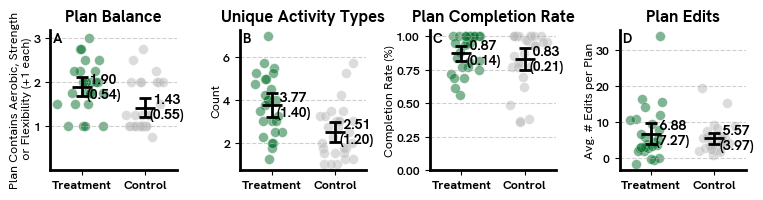

In [5]:
SUBPLOT_SPACING.update({
    'plan': {'wspace': 0.5, 'hspace': 0.0},
})

combined_metrics = {
    'plan_rounded': {
        'label': 'Plan Balance',
        'ylabel': 'Plan Contains Aerobic, Strength\n or Flexibility (+1 each)',
        'ylim': (0, 3.2),
        'yticks': [1, 2, 3]
    },
    'plan_workout_types_count': {
        'label': 'Unique Activity Types',
        'ylabel': 'Count'
    },
    'plan_completion_rate': {
        'label': 'Plan Completion Rate',
        'ylabel': 'Completion Rate (%)',
        'ylim': (0, 1.05),
    },
    'plan_edit_count': {
        'label': 'Plan Edits',
        'ylabel': 'Avg. # Edits per Plan'
    },
}

quant_df = pd.read_csv("data/daily_hk_app_usage.csv")
quant_df = quant_df[quant_df["day"] < 29]

user_averages = prepare_plan_data(quant_df)

create_faceted_dot_plots(user_averages, combined_metrics, 'plots/plan-overview.pdf', figsize=(8, 1.90))

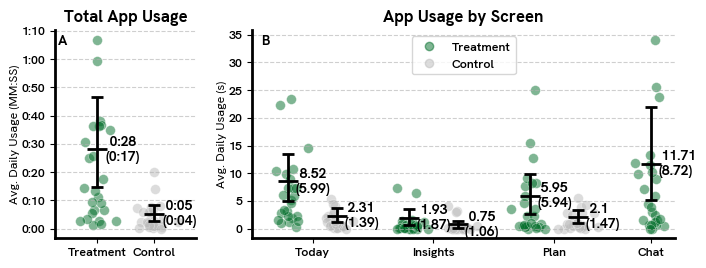


=== APP USAGE REGRESSION ANALYSIS ===

TREATMENT Condition:
  Linear regression slope: 7.986 ± 1.076 seconds/day
  R-squared: 0.679
  P-value: 0.000
  Day 1 average: 32.4 ± 30.1 seconds
  Day 28 average: 146.3 ± 44.1 seconds
  Number of days with data: 28

CONTROL Condition:
  Linear regression slope: -0.179 ± 0.362 seconds/day
  R-squared: 0.009
  P-value: 0.624
  Day 1 average: 27.2 ± 21.9 seconds
  Day 28 average: 12.0 ± 5.7 seconds
  Number of days with data: 28


In [6]:
user_averages, df_filtered, regression_results = plot_app_metrics(quant_df, figsize=(8, 2.70))

# Mindset Survey Analysis

# 

In [7]:
daily = pd.read_csv('./data/daily.csv')
weekly = pd.read_csv('./data/weekly.csv')
prepost = pd.read_csv('./data/pre_post.csv')

WEEKLY_QS = ['overall_rating_num', 'wallpaper_rating_num', 'mindset_ease_num', 'mindset_fun_num', 'barrier_total']
DAILY_QS = ['I am satisfied with my current level of physical activity._num',
       'I am a physically active person._num',
       'I am committed to my physical activity goal._num',
       'How hopeful are you about your physical health today?_num',
       'How was your mood today?_num']

weekly = weekly.dropna(subset=WEEKLY_QS)
daily = daily.dropna(subset=DAILY_QS)

def rescale(min_prev, max_prev, min_new, max_new, value):
        return (value - min_prev) / (max_prev - min_prev) * (max_new - min_new) + min_new

weekly['mindset_ease_num'] = weekly['mindset_ease_num'].apply(lambda x: rescale(1, 4, 1, 5, x))
weekly['mindset_fun_num'] = weekly['mindset_fun_num'].apply(lambda x: rescale(1, 4, 1, 5, x))
prepost['adequacy_mindset_total_norm_pre'] = prepost['adequacy_mindset_total_norm_pre'].apply(lambda x: rescale(0, 1, 1, 5, x))
prepost['adequacy_mindset_total_norm_post'] = prepost['adequacy_mindset_total_norm_post'].apply(lambda x: rescale(0, 1, 1, 5, x))
prepost['process_mindset_exercise_total_norm_pre'] = prepost['process_mindset_exercise_total_norm_pre'].apply(lambda x: rescale(0, 1, 1, 5, x))
prepost['process_mindset_exercise_total_norm_post'] = prepost['process_mindset_exercise_total_norm_post'].apply(lambda x: rescale(0, 1, 1, 5, x))
prepost['satisfaction_physical_activity_pre'] = prepost['satisfaction_physical_activity_pre'].apply(lambda x: rescale(1, 7, 1, 5, x))
prepost['satisfaction_physical_activity_post'] = prepost['satisfaction_physical_activity_post'].apply(lambda x: rescale(1, 7, 1, 5, x))
prepost['satisfaction_physical_health_pre'] = prepost['satisfaction_physical_health_pre'].apply(lambda x: rescale(1, 7, 1, 5, x))
prepost['satisfaction_physical_health_post'] = prepost['satisfaction_physical_health_post'].apply(lambda x: rescale(1, 7, 1, 5, x))

In [8]:
DAILY_ITEMS = {
    "I am a physically\nactive person": "I am a physically active person._num",
    "I am satisfied with\nmy current level of\nphysical activity": "I am satisfied with my current level of physical activity._num",
    "How hopeful are you\nabout your physical\nhealth today?": "How hopeful are you about your physical health today?_num"
}

WEEKLY_ITEMS = {
    "Exercising is…\n(boring/fun)": "mindset_fun_num",
    "Exercising is…\n(difficult/easy)": "mindset_ease_num",
}

PREPOST_ITEMS = {
    "PA Adequacy\nMindset": ['adequacy_mindset_total_norm_pre', 'adequacy_mindset_total_norm_post'],
    "PA Process\nMindset": ['process_mindset_exercise_total_norm_pre', 'process_mindset_exercise_total_norm_post'],
    "Satisfaction:\nPA Level": ['satisfaction_physical_activity_pre', 'satisfaction_physical_activity_post'],
    "Satisfaction:\nPhysical Health": ['satisfaction_physical_health_pre', 'satisfaction_physical_health_post'],
}

for q, key in DAILY_ITEMS.items():
    print(q)
    day1 = daily[daily['Day'] == 0].groupby('Condition')[key].mean()
    print(f"Day 1: T {day1['T']:.2f} C {day1['C']:.2f}")

    day28 = daily[daily['Day'] == 27].groupby('Condition')[key].mean()
    print(f"Day 28: T {day28['T']:.2f} C {day28['C']:.2f}")

    delta_t = day28['T'] - day1['T']
    delta_c = day28['C'] - day1['C']
    delta_delta = delta_t - delta_c
    print(f"Diff: T {delta_t:.2f} C {delta_c:.2f} Delta {delta_delta:.2f}")

for q, key in WEEKLY_ITEMS.items():
    print(q)
    week1 = weekly[weekly['Week'] == 1].groupby('Condition')[key].mean()
    print(f"Week 1: T {week1['T']:.2f} C {week1['C']:.2f}")

    week4 = weekly[weekly['Week'] == 4].groupby('Condition')[key].mean()
    print(f"Week 4: T {week4['T']:.2f} C {week4['C']:.2f}")

    delta_t = week4['T'] - week1['T']
    delta_c = week4['C'] - week1['C']
    delta_delta = delta_t - delta_c
    print(f"Diff: T {delta_t:.2f} C {delta_c:.2f} Delta {delta_delta:.2f}")

for q, keys in PREPOST_ITEMS.items():
    print(q)
    pre = prepost.groupby('condition')[keys[0]].mean()
    print(f"Pre: T {pre['T']:.2f} C {pre['C']:.2f}")

    post = prepost.groupby('condition')[keys[1]].mean()
    print(f"Post: T {post['T']:.2f} C {post['C']:.2f}")

    delta_t = post['T'] - pre['T']
    delta_c = post['C'] - pre['C']
    delta_delta = delta_t - delta_c
    print(f"Diff: T {delta_t:.2f} C {delta_c:.2f} Delta {delta_delta:.2f}")


I am a physically
active person
Day 1: T 2.77 C 2.53
Day 28: T 3.32 C 3.00
Diff: T 0.55 C 0.47 Delta 0.07
I am satisfied with
my current level of
physical activity
Day 1: T 2.59 C 2.71
Day 28: T 3.45 C 2.91
Diff: T 0.86 C 0.21 Delta 0.66
How hopeful are you
about your physical
health today?
Day 1: T 3.91 C 3.88
Day 28: T 4.14 C 3.87
Diff: T 0.23 C -0.01 Delta 0.24
Exercising is…
(boring/fun)
Week 1: T 3.13 C 2.81
Week 4: T 3.27 C 2.87
Diff: T 0.14 C 0.06 Delta 0.08
Exercising is…
(difficult/easy)
Week 1: T 2.92 C 2.90
Week 4: T 3.35 C 2.87
Diff: T 0.43 C -0.04 Delta 0.47
PA Adequacy
Mindset
Pre: T 2.39 C 2.59
Post: T 3.59 C 3.35
Diff: T 1.21 C 0.76 Delta 0.44
PA Process
Mindset
Pre: T 2.71 C 2.62
Post: T 3.04 C 2.84
Diff: T 0.33 C 0.22 Delta 0.11
Satisfaction:
PA Level
Pre: T 1.82 C 1.95
Post: T 3.23 C 2.98
Diff: T 1.41 C 1.02 Delta 0.39
Satisfaction:
Physical Health
Pre: T 2.28 C 2.52
Post: T 3.15 C 3.17
Diff: T 0.87 C 0.64 Delta 0.23


In [9]:
def plot_mindset_questions(
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
    prepost_df: pd.DataFrame = None,
    figsize: tuple = (8, 10),
    output_path: str = None,
    item_spacing: float = 0.6,
    bar_thickness: float = 0.25,
    label_font_size: int = 9,
    plot_title: str = 'Mindset-Related Survey Questions',
    arrow_width: float = 0.05,
    arrow_head_width: float = 0.18,
    arrow_head_length: float = 0.1,
    min_arrow_length: float = 0.05,
    helper_arrow_length: float = 0.04,
    shade_weekly_survey: bool = True,
    shade_color: str = '#F0F0F0',
    y_axis_label_offset: float = 0.25,
    label_x_offset: float = 0.04
):
    """
    Generates a single, continuous plot for survey data with section labels.
    """
    def _compute_slope_intercept(df, x_col, y_col):
        tmp = df[[x_col, y_col]].dropna()
        if len(tmp) >= 2:
            x = tmp[x_col].values
            y = tmp[y_col].values
            slope, intercept = np.polyfit(x, y, 1)
            return float(slope), float(intercept)
        return np.nan, np.nan

    data_sections = {}

    if prepost_df is not None:
        prepost_items = []
        for q, keys in PREPOST_ITEMS.items():
            pre = prepost_df.groupby('condition')[keys[0]].mean()
            post = prepost_df.groupby('condition')[keys[1]].mean()
            prepost_items.append({
                'title': q,
                'T_pre': pre.get('T', np.nan), 'T_post': post.get('T', np.nan),
                'C_pre': pre.get('C', np.nan), 'C_post': post.get('C', np.nan),
                'T_DIFF':  (prepost_df[prepost_df['condition'] == 'T'][keys[1]] - prepost_df[prepost_df['condition'] == 'T'][keys[0]]).mean(),
                'C_DIFF':  (prepost_df[prepost_df['condition'] == 'C'][keys[1]] - prepost_df[prepost_df['condition'] == 'C'][keys[0]]).mean(),
                'time_labels': ('Pre', 'Post')
            })
        if prepost_items:
            data_sections['Pre/Post Surveys'] = prepost_items

    if weekly_df is not None:
        weekly_items = []
        for q, key in WEEKLY_ITEMS.items():
            week1 = weekly_df[weekly_df['Week'] == 1].groupby('Condition')[key].mean()
            week4 = weekly_df[weekly_df['Week'] == 4].groupby('Condition')[key].mean()

            slope_t, intercept_t = _compute_slope_intercept(weekly_df[weekly_df['Condition'] == 'T'], 'Week', key)
            slope_c, intercept_c = _compute_slope_intercept(weekly_df[weekly_df['Condition'] == 'C'], 'Week', key)

            t_diff_reg = slope_t * 4 if not np.isnan(slope_t) else np.nan
            c_diff_reg = slope_c * 4 if not np.isnan(slope_c) else np.nan

            weekly_items.append({
                'title': q,
                'T_pre': week1.get('T', np.nan), 'T_post': week4.get('T', np.nan),
                'C_pre': week1.get('C', np.nan), 'C_post': week4.get('C', np.nan),
                'T_DIFF': t_diff_reg,
                'C_DIFF': c_diff_reg,
                'Slope_T': slope_t, 'Intercept_T': intercept_t,
                'Slope_C': slope_c, 'Intercept_C': intercept_c,
                'time_labels': ('Week 1', 'Week 4')
            })
        if weekly_items:
            data_sections['Weekly Survey'] = weekly_items

    if daily_df is not None:
        daily_items = []
        for q, key in DAILY_ITEMS.items():
            day1 = daily_df[daily_df['Day'] == 0].groupby('Condition')[key].mean()
            day28 = daily_df[daily_df['Day'] == 27].groupby('Condition')[key].mean()

            slope_t, intercept_t = _compute_slope_intercept(daily_df[daily_df['Condition'] == 'T'], 'Day', key)
            slope_c, intercept_c = _compute_slope_intercept(daily_df[daily_df['Condition'] == 'C'], 'Day', key)

            t_diff_reg = slope_t * 28 if not np.isnan(slope_t) else np.nan
            c_diff_reg = slope_c * 28 if not np.isnan(slope_c) else np.nan

            daily_items.append({
                'title': q,
                'T_pre': day1.get('T', np.nan), 'T_post': day28.get('T', np.nan),
                'C_pre': day1.get('C', np.nan), 'C_post': day28.get('C', np.nan),
                'T_DIFF': t_diff_reg,
                'C_DIFF': c_diff_reg,
                'Slope_T': slope_t, 'Intercept_T': intercept_t,
                'Slope_C': slope_c, 'Intercept_C': intercept_c,
                'time_labels': ('Day 1', 'Day 28')
            })
        if daily_items:
            data_sections['Daily Survey'] = daily_items

    if not data_sections:
        print("No data to plot.")
        return None, None

    all_items = []
    section_info = {}
    section_display_order = ['Daily Survey', 'Weekly Survey', 'Pre/Post Surveys']

    for section_name in section_display_order:
        if section_name in data_sections:
            for item in data_sections[section_name]:
                item['section'] = section_name
                all_items.append(item)

    y_pos, y_positions, y_ticks, y_tick_labels = 0, [], [], []
    current_section = None
    for item_idx, item in enumerate(all_items):
        y_positions.append(y_pos)
        y_ticks.append(y_pos)
        y_tick_labels.append(item['title'])

        if item['section'] not in section_info:
            section_info[item['section']] = {'y_values': []}
        section_info[item['section']]['y_values'].append(y_pos)

        current_section = item['section']
        y_pos -= item_spacing

    min_y = min(y_positions)
    y_positions = [y - min_y for y in y_positions]
    y_ticks = [y - min_y for y in y_ticks]

    for section_name in section_info:
        section_info[section_name]['y_values'] = [y - min_y for y in section_info[section_name]['y_values']]

    fig, ax = plt.subplots(figsize=figsize)

    for i, item in enumerate(all_items):
        y_center = y_positions[i]
        c_y_pos = y_center - bar_thickness / 2
        t_y_pos = y_center + bar_thickness / 2
        l_offset = label_x_offset
        for group, y_pos_group, color in [('T', t_y_pos, COLORS['T']), ('C', c_y_pos, COLORS['C'])]:
            pre = item[f'{group}_pre']
            post = item[f'{group}_post']

            # keep references for label x-placement (both conditions)
            pre_t = item.get('T_pre', np.nan)
            post_t = item.get('T_post', np.nan)
            pre_c = item.get('C_pre', np.nan)
            post_c = item.get('C_post', np.nan)

            if pd.isna(pre) or pd.isna(post):
                continue

            change = post - pre

            if abs(change) >= min_arrow_length:
                ax.arrow(
                    pre, y_pos_group, dx=(post - pre), dy=0,
                    width=arrow_width,
                    head_width=arrow_head_width, head_length=arrow_head_length,
                    length_includes_head=True,
                    color=color, zorder=4
                )
                ax.scatter(pre, y_pos_group, s=50, color=color, zorder=5, clip_on=False)
            else:
                if abs(change) > 0.001:
                    direction = np.sign(change)
                    start_x = post - (direction * helper_arrow_length)
                    ax.arrow(
                        start_x, y_pos_group, dx=direction * helper_arrow_length * 2, dy=0,
                        width=arrow_width,
                        head_width=arrow_head_width, head_length=arrow_head_length,
                        length_includes_head=True,
                        color=color, zorder=4, antialiased=False
                    )

            mean_change = item.get(f'{group}_DIFF', np.nan)
            # For regression-based deltas we store them in T_DIFF / C_DIFF, so mean_change is actually the regression delta now.
            label_text = (
                f"{item['time_labels'][0]}: {pre:.2f} → "
                f"{item['time_labels'][1]}: {post:.2f} (Δ={mean_change:+.2f})"
            )

            label_x = max(np.nan_to_num(pre_t, nan=0.0), np.nan_to_num(post_t, nan=0.0),
                          np.nan_to_num(pre_c, nan=0.0), np.nan_to_num(post_c, nan=0.0)) + l_offset
            ax.text(
                label_x, y_pos_group, label_text,
                ha='left', va='center', fontsize=label_font_size, zorder=10
            )

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_tick_labels, ha='right')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1\nStrongly Disagree', '2', '3', '4', '5\nStrongly Agree'])
    ax.set_xlabel('Average Score (Likert Scale)')
    ax.set_xlim(1, 5.5)

    ax.set_ylim(min(y_ticks) - item_spacing * 0.75, max(y_ticks) + item_spacing * 0.75)

    ax.spines['left'].set_position(('outward', 0))
    ax.spines['left'].set_bounds(ax.get_ylim()[0], ax.get_ylim()[1])

    for section_name in section_display_order:
        if section_name in section_info:
            y_values_in_section = section_info[section_name]['y_values']
            y_mid = np.mean(y_values_in_section)
            ax.text(
                -y_axis_label_offset, y_mid, section_name,
                ha='center', va='center', rotation=90,
                fontsize=10, fontweight='bold',
                transform=ax.get_yaxis_transform(),
                clip_on=False
            )

    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_bounds(1, 5)

    fig.text(0.375, 0.96, plot_title, fontsize=16, fontweight='bold', ha='left', va='center')

    legend_ax = fig.add_axes([0.825, 0.93, 0.2, 0.06])
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 2)
    legend_ax.axis('off')

    arrow_start, arrow_length_leg, marker_s_leg = 0.2, 0.15, 50
    y_pos_t_leg, y_pos_c_leg = 1.25, 0.6

    legend_ax.arrow(arrow_start, y_pos_t_leg, arrow_length_leg, 0, width=arrow_width * 5, head_width=arrow_head_width * 4, head_length=arrow_head_length * 0.66, length_includes_head=True, color=COLORS['T'], alpha=0.8, zorder=4)
    legend_ax.scatter([arrow_start], [y_pos_t_leg], s=marker_s_leg, facecolors=COLORS['T'], edgecolors='none', zorder=5)
    legend_ax.text(0.425, y_pos_t_leg, 'Treatment', ha='left', va='center', fontsize=9)

    legend_ax.arrow(arrow_start, y_pos_c_leg, arrow_length_leg, 0, width=arrow_width * 5, head_width=arrow_head_width * 4, head_length=arrow_head_length * 0.66, length_includes_head=True, color=COLORS['C'], alpha=0.8, zorder=4)
    legend_ax.scatter([arrow_start], [y_pos_c_leg], s=marker_s_leg, facecolors=COLORS['C'], edgecolors='none', zorder=5)
    legend_ax.text(0.425, y_pos_c_leg, 'Control', ha='left', va='center', fontsize=9)

    plt.tight_layout(rect=[0.1, 0.05, 1, 0.93])

    fig.canvas.draw()

    # draw weekly shading only if weekly section exists and user wants it
    if 'Weekly Survey' in section_info and shade_weekly_survey:
        weekly_y = section_info['Weekly Survey']['y_values']
        y_span_lower = min(weekly_y) - item_spacing / 2
        y_span_upper = max(weekly_y) + item_spacing / 2

        y0_px = ax.transData.transform((0.0, y_span_lower))[1]
        y1_px = ax.transData.transform((0.0, y_span_upper))[1]

        _, y0_fig = fig.transFigure.inverted().transform((0.0, y0_px))
        _, y1_fig = fig.transFigure.inverted().transform((0.0, y1_px))

        rect = Rectangle(
            (0.15, y0_fig),                # x0, y0 in figure coords
            0.875,                          # full figure width
            y1_fig - y0_fig,              # height in figure coords
            transform=fig.transFigure,    # use figure coordinates
            color=shade_color,
            alpha=0.7,
            zorder=1,
            clip_on=False
        )
        fig.patches.append(rect)

    try:
        ax.set_zorder(3)
        ax.patch.set_alpha(0.0)

        for patch in list(ax.patches):
            patch.set_zorder(max(getattr(patch, 'zorder', 3), 10))

        for coll in ax.collections:
            coll.set_zorder(max(getattr(coll, 'zorder', 3), 12))

        for line in ax.lines:
            line.set_zorder(max(getattr(line, 'zorder', 3), 12))

        for text in ax.texts:
            text.set_zorder(max(getattr(text, 'zorder', 3), 15))

        for spine in ax.spines.values():
            spine.set_zorder(20)
        for lbl in ax.get_yticklabels() + ax.get_xticklabels():
            lbl.set_zorder(20)
        for tl in ax.xaxis.get_ticklines() + ax.yaxis.get_ticklines():
            tl.set_zorder(20)
        ax.xaxis.label.set_zorder(20)
        ax.yaxis.label.set_zorder(20)

        for gridline in ax.get_xgridlines() + ax.get_ygridlines():
            gridline.set_zorder(6)

        if 'legend_ax' in locals():
            try:
                legend_ax.set_zorder(30)
                legend_ax.patch.set_alpha(0.0)
                for la in legend_ax.texts:
                    la.set_zorder(40)
                for p in list(legend_ax.patches):
                    p.set_zorder(35)
                for c in legend_ax.collections:
                    c.set_zorder(35)
                for l in legend_ax.lines:
                    l.set_zorder(35)
            except Exception:
                pass

    except Exception as e:
        print(f"Warning when adjusting z-orders: {e}")

    if output_path:
        fig.savefig(output_path, bbox_inches='tight', dpi=300)

    plt.show()
    return fig, ax


/tmp/ipykernel_165740/3623127565.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.1, 0.05, 1, 0.93])


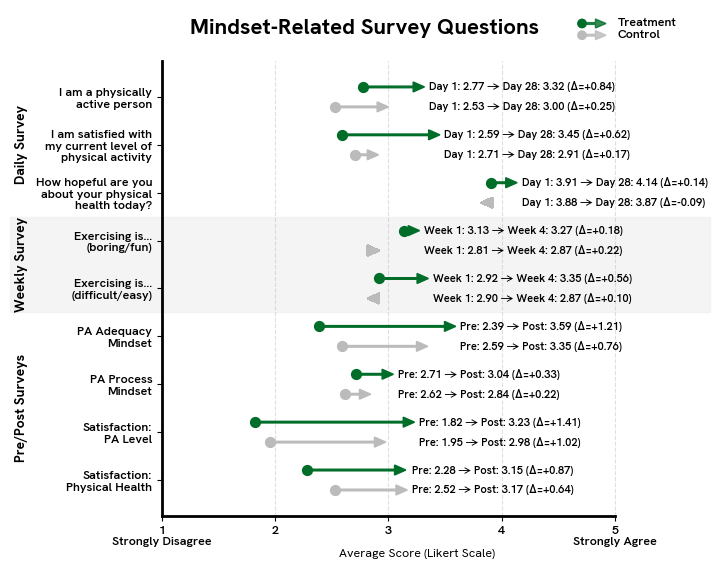

In [10]:
fig, axes = plot_mindset_questions(
    daily_df=daily,
    weekly_df=weekly, 
    prepost_df=prepost,
    plot_title='Mindset-Related Survey Questions',
    output_path="plots/mindset-arrows.pdf",
    label_font_size=8,
    item_spacing=0.6,
    bar_thickness=0.25,
    arrow_width=0.02,
    arrow_head_width=0.125,
    arrow_head_length=0.1,
    min_arrow_length=0.07,
    helper_arrow_length=0.05,
    shade_weekly_survey=True,
    shade_color="#F0F0F02B",
    y_axis_label_offset=0.275,
    figsize=(8, 6)
)